In [1]:
import pandas as pd
from pathlib import Path

In [2]:
PROJECT_ROOT = Path().resolve().parent

INPUT_FILE = PROJECT_ROOT / "03_processed_data/day8_time_normalized_supply_data.csv"
OUTPUT_FILE = PROJECT_ROOT / "03_processed_data/day9_vendor_kpi.csv"

df = pd.read_csv(INPUT_FILE)

In [4]:
df["total_procurement_cost"] = df["quantity"] * df["cost_per_kg"]

In [6]:
vendor_kpi = df.groupby("vendor_name").agg({
    "quantity": "sum",
    "cost_per_kg": "mean",
    "defect_rate_pct": "mean",
    "total_procurement_cost": "sum"
}).reset_index()

vendor_kpi.columns = [
    "vendor_name",
    "total_quantity",
    "avg_cost_per_kg",
    "avg_defect_rate",
    "total_procurement_cost"
]

In [7]:
total_quantity_all = vendor_kpi["total_quantity"].sum()

vendor_kpi["contribution_pct"] = (
    vendor_kpi["total_quantity"] / total_quantity_all
) * 100

In [8]:
#Top and Bottom Vendors
top_suppliers = vendor_kpi.sort_values(
    "total_quantity", ascending=False
).head(5)

worst_suppliers = vendor_kpi.sort_values(
    "avg_defect_rate", ascending=False
).head(5)

top_suppliers.to_csv(
    PROJECT_ROOT / "03_processed_data/top_suppliers.csv",
    index=False
)

worst_suppliers.to_csv(
    PROJECT_ROOT / "03_processed_data/worst_suppliers.csv",
    index=False
)

<Figure size 640x480 with 0 Axes>

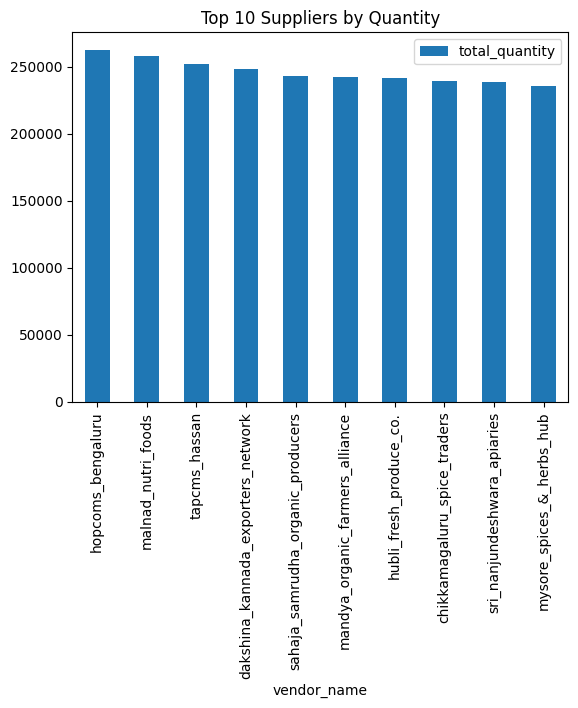

In [10]:
import matplotlib.pyplot as plt

plt.figure()

vendor_kpi.sort_values("total_quantity", ascending=False).head(10).plot(
    x="vendor_name",
    y="total_quantity",
    kind="bar"
)

plt.title("Top 10 Suppliers by Quantity")

plt.savefig(
    PROJECT_ROOT / "04_visualizations/top_suppliers_quantity.png"
)
plt.show()
plt.close()

In [11]:
#Detect Low-Quality Vendors

low_quality = vendor_kpi[
    vendor_kpi["avg_defect_rate"] > vendor_kpi["avg_defect_rate"].mean()
]

low_quality.to_csv(
    PROJECT_ROOT / "03_processed_data/low_quality_suppliers.csv",
    index=False
)